In [1]:
import numpy as np
import matplotlib.pyplot as plt
import neuralfoil as nf
from scipy.optimize import bisect

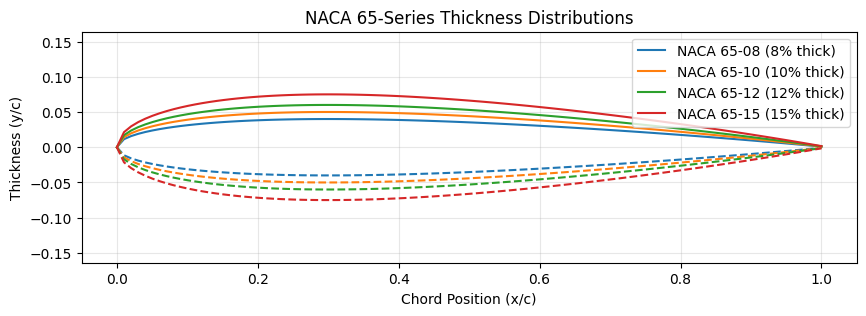

In [17]:
a0, a1, a2, a3, a4 = 0.2969, -0.1260, -0.3516, 0.2843, -0.1015

def naca65_thickness(x, thickness_ratio):
    """NACA 65-series thickness distribution"""
    return (thickness_ratio/0.2) * (a0*np.sqrt(x) + a1*x + a2*x**2 + a3*x**3 + a4*x**4)

# Example: Plot thickness distribution
x = np.linspace(0, 1, 100)
thicknesses = [0.08, 0.10, 0.12, 0.15]

plt.figure(figsize=(10, 3))
for t in thicknesses:
    yt = naca65_thickness(x, t)
    plt.plot(x, yt, label=f'NACA 65-{int(t*100):02d} ({t*100:.0f}% thick)')
    plt.plot(x, -yt, '--', color=plt.gca().lines[-1].get_color())

plt.xlabel('Chord Position (x/c)')
plt.ylabel('Thickness (y/c)')
plt.title('NACA 65-Series Thickness Distributions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [11]:
def circular_arc_camber(x, design_CL):
    """
    CORRECT Circular arc camber line
    design_CL: Target lift coefficient from radial equilibrium
    """
    # Convert design CL to maximum camber using thin airfoil theory
    g = design_CL / (2 * np.pi)
    h = g * 0.25  # Maximum camber height at mid-chord

    print(f"Design CL = {design_CL:.3f}")
    print(f"Maximum camber = {h*100:.2f}% of chord")

    # Symmetric airfoil for zero camber
    if h < 1e-6:
        return np.zeros_like(x), np.zeros_like(x)

    # Radius of circular arc
    R = (0.25 + h**2) / (2 * h)

    yc = np.sqrt(np.maximum(R**2 - (x - 0.5)**2, 0)) + h - R

    # Derivative (slope)
    with np.errstate(divide='ignore', invalid='ignore'):
        dyc_dx = (x - 0.5) / np.sqrt(np.maximum(R**2 - (x - 0.5)**2, 1e-12))
        dyc_dx = np.nan_to_num(dyc_dx, nan=0.0, posinf=0.0, neginf=0.0)

    # Calculate leading and trailing edge angles
    le_angle = np.rad2deg(np.arctan(dyc_dx[0]))  # Slope at x=0
    te_angle = np.rad2deg(np.arctan(dyc_dx[-1])) # Slope at x=1

    print(f"Leading edge angle = {le_angle:.2f}°")
    print(f"Trailing edge angle = {te_angle:.2f}°")
    print(f"Circular arc radius = {R:.3f} chord lengths")

    # Verification
    yc_mid = yc[len(yc)//2]  # Camber at mid-chord
    yc_le = yc[0]            # Camber at leading edge
    yc_te = yc[-1]           # Camber at trailing edge

    print(f"Verification: yc(0.5) = {yc_mid:.6f} (should be {h:.6f})")
    print(f"Verification: yc(0) = {yc_le:.6f} (should be 0)")
    print(f"Verification: yc(1) = {yc_te:.6f} (should be 0)")

    return yc, dyc_dx


Design CL = 0.500
Maximum camber = 1.99% of chord
Leading edge angle = -4.56°
Trailing edge angle = 4.56°
Circular arc radius = 6.293 chord lengths
Verification: yc(0.5) = 0.019892 (should be 0.019894)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)
Design CL = 1.000
Maximum camber = 3.98% of chord
Leading edge angle = -9.10°
Trailing edge angle = 9.10°
Circular arc radius = 3.161 chord lengths
Verification: yc(0.5) = 0.039785 (should be 0.039789)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)
Design CL = 1.500
Maximum camber = 5.97% of chord
Leading edge angle = -13.61°
Trailing edge angle = 13.61°
Circular arc radius = 2.124 chord lengths
Verification: yc(0.5) = 0.059677 (should be 0.059683)
Verification: yc(0) = 0.000000 (should be 0)
Verification: yc(1) = 0.000000 (should be 0)
Design CL = 2.000
Maximum camber = 7.96% of chord
Leading edge angle = -18.09°
Trailing edge angle = 18.09°
Circular arc r

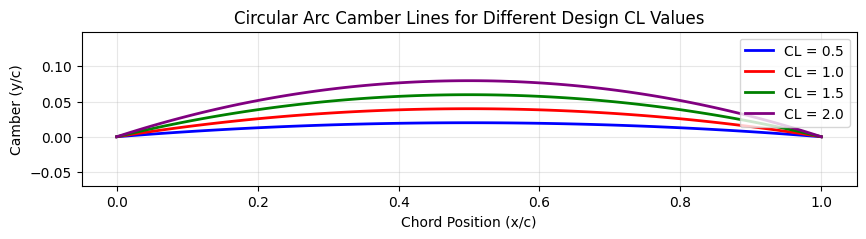

In [16]:
plt.figure(figsize=(10, 2))
design_CL_values = [0.5, 1.0, 1.5, 2.0]
colors = ['blue', 'red', 'green', 'purple']

for CL, color in zip(design_CL_values, colors):
    yc, _ = circular_arc_camber(x, CL)
    plt.plot(x, yc, color=color, linewidth=2, label=f'CL = {CL}')

plt.xlabel('Chord Position (x/c)')
plt.ylabel('Camber (y/c)')
plt.title('Circular Arc Camber Lines for Different Design CL Values')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()